In [1]:
from langgraph.graph import StateGraph , START, END
from typing import TypedDict, Literal
from dotenv import load_dotenv
import os
from pydantic import BaseModel, Field
from langchain_groq import ChatGroq



In [2]:
load_dotenv()

True

In [3]:
llm = ChatGroq(
    model="llama-3.1-8b-instant",
    api_key= os.getenv("GROQ_API_KEY")
)

print(llm.invoke("Hello").content)


Hello. How can I assist you today?


In [4]:
# define pydentic schema 

class SentimentSchema(BaseModel):
    sentiment: Literal['positive','negative'] = Field(description='Sentiment of the review')


In [5]:
# pydantic schema for diagnosis
class DiagnosisSchema(BaseModel):
    issue_type: Literal['UX','Performance','Bug','Support','Other'] = Field(description='the category of the issue mentioned in the review')
    tone: Literal['anger', 'frustation','disappointed','calm'] = Field(description='The emotional tone expressed by the user')
    urgency : Literal['Low','medium','high'] = Field(description='How urgent or critical is issue appears to be')
    


In [6]:
structured_model = llm.with_structured_output(SentimentSchema)
structured_model2 = llm.with_structured_output(DiagnosisSchema)

In [7]:
prompt = 'what is the sentiment of the following review - the software is too bad'
res= structured_model.invoke(prompt)

In [8]:
res

SentimentSchema(sentiment='negative')

In [9]:
class ReviewState(TypedDict):
    review : str
    sentiment: Literal['positive','negetive']
    diagnosis : dict
    response : str

In [42]:
def find_sentiment(state:ReviewState):
    prompt = f'for the following review find out the sentiment \n {state['review']} '
    sentiment = structured_model.invoke(prompt).sentiment
    return {
        'sentiment' : sentiment
    }


def check_sentiment(state:ReviewState) -> Literal['positive_response', 'run_diagnosis']:
    if state['sentiment'] =='positive':
        return 'positive_response'
    else:
        return 'run_diagnosis'

def positive_response(state:ReviewState):
    prompt = f""" write a warm thank you message in response to this review:
    - Do NOT add introductions like "Here is"

    \n\n  "{state['review']}" \n
    Also, kindly ask the user to leave feedback on our website 
    """    
    response = llm.invoke(prompt)
    return {
        'response' : response
    }

def run_diagnosis(state:ReviewState):
    prompt = f""" Diagnose this negetive review: \n\n {state['review']} \n
    return issue_type, tone and urgency 
      
    """
    res = structured_model2.invoke(prompt)    
    return {
        'diagnosis' : res.model_dump()
    }

def negetive_response(state:ReviewState):
    diagnosis = state['diagnosis']
    prompt = f""" You are a support Assistant.
    The user had {diagnosis['issue_type']} issue, sounded {diagnosis['tone']} 
    and marked urgency as {diagnosis['urgency']}.
    write an empathic, helpful and resolution message.
    - Do NOT add introductions like "Here is, "urgent response , etc"
 


    """
    response = llm.invoke(prompt).content
    return{
        'response' : response
    }




In [43]:
graph = StateGraph(ReviewState)

# add node 
graph.add_node('find_sentiment', find_sentiment)
graph.add_node('positive_response', positive_response)
graph.add_node('run_diagnosis', run_diagnosis)
graph.add_node('negetive_response', negetive_response)

# add edges 
graph.add_edge(START,'find_sentiment')

graph.add_conditional_edges('find_sentiment',check_sentiment)
graph.add_edge('positive_response',END)

graph.add_edge('run_diagnosis', 'negetive_response')
graph.add_edge('negetive_response',END)

workflow = graph.compile()

In [20]:
res = workflow.invoke({
    'review' : "The product exceeded expectations in every way. The build quality feels solid, performance is smooth, and it delivers exactly what it promises. Setup was simple and everything worked without any hassle. It has made daily use more convenient and reliable, and it clearly stands out compared to similar options."
})

In [26]:
#positive response
res['response'].content

'"We\'re thrilled to hear that our product has exceeded your expectations in every way. It\'s wonderful to know that you\'re enjoying the build quality, performance, and reliability. Your positive experience is what drives us to continue improving and delivering exceptional results.\n\nWe\'re grateful for your kind words and would love to hear more about your experience on our website. If you could spare a moment to share your feedback, it would be a great help to us in understanding what we\'re doing right and where we can improve. Your input is invaluable in helping us create the best products for our customers."'

In [44]:
re = workflow.invoke({
    'review':"The product was disappointing overall. The build quality feels cheap and not durable. It does not perform as expected and often lags or fails during normal use. Setup was confusing and took more time than it should have. It does not match the features or value that were advertised, and there are better alternatives available at this price."
})

In [45]:
re

{'review': 'The product was disappointing overall. The build quality feels cheap and not durable. It does not perform as expected and often lags or fails during normal use. Setup was confusing and took more time than it should have. It does not match the features or value that were advertised, and there are better alternatives available at this price.',
 'sentiment': 'negative',
 'diagnosis': {'issue_type': 'Performance',
  'tone': 'disappointed',
  'urgency': 'high'},
 'response': "I can sense your frustration with the performance issue you're experiencing, and I want to assure you that I'm here to help resolve it as quickly as possible. Your feedback has been noted, and I'm escalating this issue to our dedicated support team who will work closely with you to identify the root cause and provide a prompt solution.\n\nTo better assist you, could you please provide more details about the performance issue you're facing, such as when it started, what actions you've tried so far, and any e

In [46]:
re['response']

"I can sense your frustration with the performance issue you're experiencing, and I want to assure you that I'm here to help resolve it as quickly as possible. Your feedback has been noted, and I'm escalating this issue to our dedicated support team who will work closely with you to identify the root cause and provide a prompt solution.\n\nTo better assist you, could you please provide more details about the performance issue you're facing, such as when it started, what actions you've tried so far, and any error messages you've encountered? This information will enable us to investigate and resolve the issue efficiently.\n\nIn the meantime, I've initiated a priority ticket for your case, and our support team will be in touch with you shortly to discuss a plan of action. We appreciate your patience and cooperation in this matter, and we're committed to getting your issue resolved as soon as possible.\n\nPlease feel free to share any additional information or context that might be helpfu

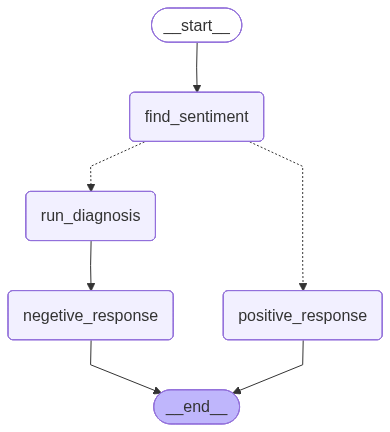

In [14]:
workflow